<a href="https://colab.research.google.com/github/sham404-essa/ai-chat-project/blob/main/Copy_of_kmeans_churn_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering for Customer Churn Analysis

## Business Problem

A telecom company is losing customers to competitors. The retention team cannot call every customer — they need to know **which customers are most at risk of churning** and what they look like, so they can target interventions efficiently.

### Our approach
We will use **K-Means clustering** to segment customers by usage behavior and account characteristics — **without looking at the churn label**. Then we will overlay the churn label on top to discover which segments are high-risk.

This mirrors real-world practice: clustering reveals natural customer archetypes, and churn labels help us prioritize which archetypes to act on.

### Dataset: IBM Telco Customer Churn
- ~7,000 telecom customers
- Features: contract type, tenure, monthly charges, services subscribed, payment method
- Target column: `Churn` (Yes/No) — used only for post-hoc validation

---

## 0 — Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
print('All imports OK')

All imports OK


---
## 1 — Download the Dataset

In [ ]:
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

df_raw = pd.read_csv(URL)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print('Column types:')
print(df_raw.dtypes)
print()
print('Missing values per column:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
Series([], dtype: int64)


In [ ]:
print('Churn distribution:')
print(df_raw['Churn'].value_counts())
print(f'\nChurn rate: {(df_raw["Churn"]=="Yes").mean():.1%}')

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


---
## 2 — Data Cleaning

In [ ]:
df = df_raw.copy()

# TotalCharges is read as object due to spaces — coerce to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'NaN in TotalCharges after coerce: {df["TotalCharges"].isna().sum()}')

# These are new customers with 0 tenure — fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID — not a feature
df = df.drop(columns=['customerID'])

# Save churn label separately before encoding anything
churn_label = (df['Churn'] == 'Yes').astype(int)

print(f'\nCleaned shape: {df.shape}')
print(f'Churn label: {churn_label.sum()} churned out of {len(churn_label)}')

NaN in TotalCharges after coerce: 11

Cleaned shape: (7043, 20)
Churn label: 1869 churned out of 7043


In [ ]:
# Quick look at numeric distributions
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


In [ ]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:')
for c in cat_cols:
    print(f'  {c}: {df[c].unique()[:5]}')

Categorical columns:
  gender: ['Female' 'Male']
  Partner: ['Yes' 'No']
  Dependents: ['No' 'Yes']
  PhoneService: ['No' 'Yes']
  MultipleLines: ['No phone service' 'No' 'Yes']
  InternetService: ['DSL' 'Fiber optic' 'No']
  OnlineSecurity: ['No' 'Yes' 'No internet service']
  OnlineBackup: ['Yes' 'No' 'No internet service']
  DeviceProtection: ['No' 'Yes' 'No internet service']
  TechSupport: ['No' 'Yes' 'No internet service']
  StreamingTV: ['No' 'Yes' 'No internet service']
  StreamingMovies: ['No' 'Yes' 'No internet service']
  Contract: ['Month-to-month' 'One year' 'Two year']
  PaperlessBilling: ['Yes' 'No']
  PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  Churn: ['No' 'Yes']


---
## 3 — Feature Selection & Engineering

### Which features are useful for customer segmentation?

We want features that capture **customer behavior and relationship with the company**, not administrative IDs.

| Feature category | Examples | Why useful |
|-----------------|----------|------------|
| Account age | `tenure` | Long vs new customers behave differently |
| Financial | `MonthlyCharges`, `TotalCharges` | High-value vs low-value customers |
| Contract | `Contract`, `PaperlessBilling` | Commitment level |
| Services | `InternetService`, `StreamingTV`, etc. | Product engagement |
| Payment | `PaymentMethod` | Friction / automation level |

We **exclude** `Churn` — it would leak the answer into the clustering.

In [ ]:
SELECTED = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'PaymentMethod',
    'InternetService',
    'OnlineSecurity',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'SeniorCitizen',
    'Dependents',
    'Partner',
]

X_raw = df[SELECTED].copy()

# Encode categoricals: binary → 0/1, multi-class → ordinal or dummies
binary_map = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
binary_cols = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling', 'Dependents', 'Partner']
for c in binary_cols:
    X_raw[c] = X_raw[c].map(binary_map)

# Contract: ordinal encoding (month-to-month = 0, one year = 1, two year = 2)
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
X_raw['Contract'] = X_raw['Contract'].map(contract_map)

# SeniorCitizen already 0/1

# One-hot encode remaining multi-class categoricals
X_raw = pd.get_dummies(X_raw, columns=['PaymentMethod', 'InternetService'], drop_first=False)

print(f'Feature matrix shape: {X_raw.shape}')
X_raw.head()

Feature matrix shape: (7043, 19)


,tenure,MonthlyCharges,TotalCharges,Contract,OnlineSecurity,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,SeniorCitizen,Dependents,Partner,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,1,29.85,29.85,0,0,0,0,0,1,0,0,1,False,False,True,False,True,False,False
1,34,56.95,1889.50,1,1,0,0,0,0,0,0,0,False,False,False,True,True,False,False
2,2,53.85,108.15,0,1,0,0,0,1,0,0,0,False,False,False,True,True,False,False
3,45,42.30,1840.75,1,1,1,0,0,0,0,0,0,True,False,False,False,True,False,False
4,2,70.70,151.65,0,0,0,0,0,1,0,0,0,False,False,True,False,False,True,False


In [ ]:
# Scale: K-Means is distance-based — scaling is mandatory
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f'Scaled matrix shape: {X.shape}')
print(f'Mean per feature (should be ~0): {X.mean(axis=0).round(3)}')

Scaled matrix shape: (7043, 19)
Mean per feature (should be ~0): [-0. -0. -0. -0. -0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0.
  0.]


---
## 4 — The Business Problem: Customer Segmentation for Retention

### Why K-Means for churn?

Churn is not random — it concentrates in **specific customer archetypes**:
- New customers on month-to-month contracts who haven't engaged yet
- High-paying customers who feel they're not getting value
- Customers who called support but weren't satisfied

A churn model (classification) tells you *who* will churn. A clustering model tells you *why* and *how many like them exist*. Together, they power targeted retention campaigns.

### Our pipeline
1. Cluster customers by behavior (no churn label)
2. Overlay churn label onto clusters
3. Identify the highest-risk segments
4. Describe each segment → craft targeted offers

---

## 5 — Choosing the Best K: Elbow Method + Silhouette

In [ ]:
K_RANGE = range(2, 12)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels, sample_size=2000, random_state=42))
    print(f'k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

k= 2  inertia=110,549  silhouette=0.1618
k= 3  inertia=95,344  silhouette=0.1790
k= 4  inertia=84,869  silhouette=0.1897
k= 5  inertia=79,258  silhouette=0.1842
k= 6  inertia=75,935  silhouette=0.1743
k= 7  inertia=72,641  silhouette=0.1580
k= 8  inertia=70,050  silhouette=0.1638
k= 9  inertia=68,032  silhouette=0.1650
k=10  inertia=66,365  silhouette=0.1609
k=11  inertia=63,682  silhouette=0.1706


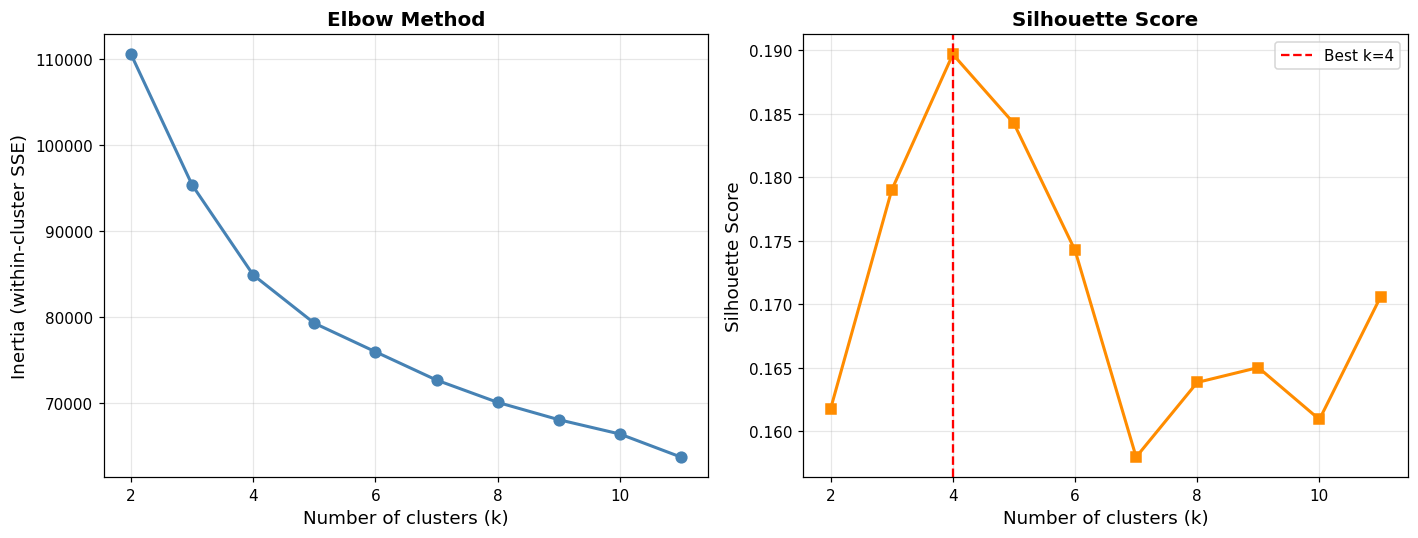


Best silhouette at k=4


In [ ]:
# Elbow plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.set_xlabel('Number of clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (within-cluster SSE)', fontsize=12)
ax1.set_title('Elbow Method', fontweight='bold', fontsize=13)
ax1.grid(alpha=0.3)

best_k_sil = list(K_RANGE)[np.argmax(sil_scores)]
ax2.plot(list(K_RANGE), sil_scores, 's-', color='darkorange', linewidth=2, markersize=7)
ax2.axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
ax2.set_xlabel('Number of clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\nBest silhouette at k={best_k_sil}')

In [ ]:
# Acceleration (second derivative of inertia) — elbow detection
inertia_arr = np.array(inertias)
accel = np.diff(inertia_arr, 2)
k_elbow = list(K_RANGE)[accel.argmax() + 1]
print(f'Elbow method suggests k={k_elbow}')
print(f'Silhouette method suggests k={best_k_sil}')

Elbow method suggests k=4
Silhouette method suggests k=4


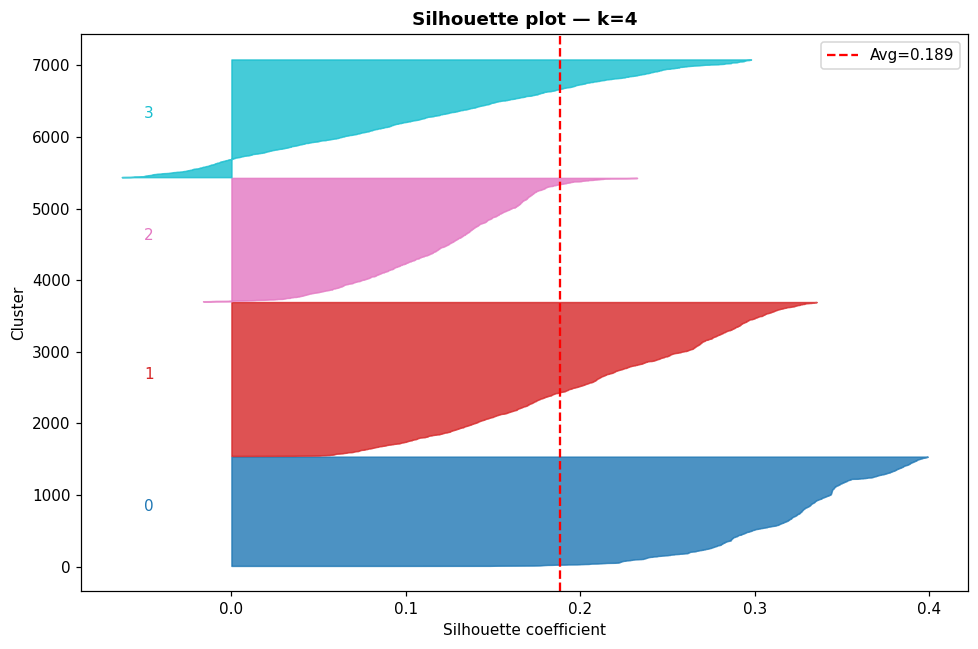

In [ ]:
# Silhouette plot for chosen k
K_FINAL = 4   # adjust after inspecting elbow — common landing point for this dataset

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X)

# Per-sample silhouette
sil_vals = silhouette_samples(X, cluster_labels)
avg_sil  = sil_vals.mean()

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    c_vals = np.sort(sil_vals[cluster_labels == i])
    c_size = len(c_vals)
    y_upper = y_lower + c_size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals, color=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * c_size, str(i), fontsize=10, color=colors[i])
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg={avg_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette plot — k={K_FINAL}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### ✏️ Question 5.1 — Choosing K

1. Looking at the elbow plot: where does the curve "bend"? Is it a sharp or gradual elbow?
2. Do the elbow method and silhouette method agree on the best k?
3. What business constraint might lead you to choose a higher k than the algorithm suggests?

**Your answer:**

1. The elbow appears around k = 4. The curve shows a gradual elbow rather than a sharp bend, indicating that adding more clusters beyond 4 provides diminishing improvements in reducing inertia.
2. Yes. Both methods suggest k = 4 as the optimal number of clusters. The silhouette score reaches its maximum value at k = 4, and the elbow plot also shows the main bend around the same point.
3. A business may choose a higher number of clusters if it wants more detailed customer segments for targeted marketing and retention campaigns. Even if k = 4 is statistically optimal, using k = 5 or k = 6 could help identify smaller customer groups with different behaviors and allow more personalized business actions.

---
## 6 — Cluster Profiles: Who Is in Each Segment?

In [ ]:
# Attach cluster labels and churn back to the original (unscaled) data for interpretation
df_clustered = X_raw.copy()
df_clustered['cluster'] = cluster_labels
df_clustered['churn']   = churn_label.values

# Original numeric features for readability
df_clustered['tenure_raw']         = df['tenure'].values
df_clustered['MonthlyCharges_raw'] = df['MonthlyCharges'].values
df_clustered['Contract_raw']       = df['Contract'].values

print('Cluster sizes:')
print(df_clustered['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    1526
1    2149
2    1724
3    1644
Name: count, dtype: int64


In [ ]:
# Mean of key features per cluster (original scale)
profile_cols = ['tenure_raw', 'MonthlyCharges_raw', 'Contract',
                'OnlineSecurity', 'TechSupport', 'StreamingTV',
                'PaperlessBilling', 'SeniorCitizen', 'Partner', 'Dependents']

profiles = df_clustered.groupby('cluster')[profile_cols].mean().round(2)
profiles.columns = ['Tenure (months)', 'Monthly Charges ($)', 'Contract (0=Mo, 2=2yr)',
                    'Online Security', 'Tech Support', 'Streaming TV',
                    'Paperless Billing', 'Senior Citizen', 'Has Partner', 'Has Dependents']
print('Cluster feature profiles:')
profiles

Cluster feature profiles:


,Tenure (months),Monthly Charges ($),"Contract (0=Mo, 2=2yr)",Online Security,Tech Support,Streaming TV,Paperless Billing,Senior Citizen,Has Partner,Has Dependents
cluster,,,,,,,,,,
0,30.55,21.08,1.07,0.00,0.00,0.00,0.29,0.03,0.48,0.42
1,20.82,86.46,0.08,0.14,0.14,0.46,0.79,0.30,0.37,0.15
2,21.32,51.76,0.36,0.38,0.35,0.26,0.55,0.11,0.36,0.27
3,60.76,90.59,1.48,0.65,0.69,0.78,0.66,0.16,0.75,0.41


In [ ]:
print(df_clustered[profile_cols].dtypes)

tenure_raw              int64
MonthlyCharges_raw    float64
Contract_raw           object
OnlineSecurity          int64
TechSupport             int64
StreamingTV             int64
PaperlessBilling        int64
SeniorCitizen           int64
Partner                 int64
Dependents              int64
dtype: object


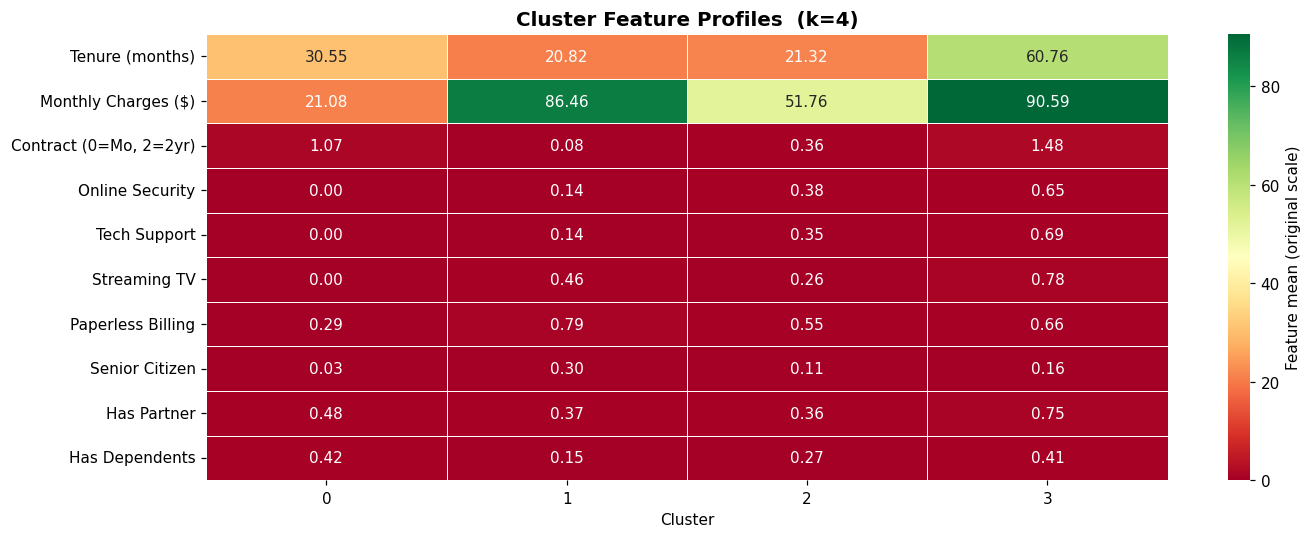

In [ ]:
# Heatmap of cluster profiles
plt.figure(figsize=(13, 5))
sns.heatmap(
    profiles.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.4,
    cbar_kws={'label': 'Feature mean (original scale)'},
)
plt.title(f'Cluster Feature Profiles  (k={K_FINAL})', fontweight='bold', fontsize=13)
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

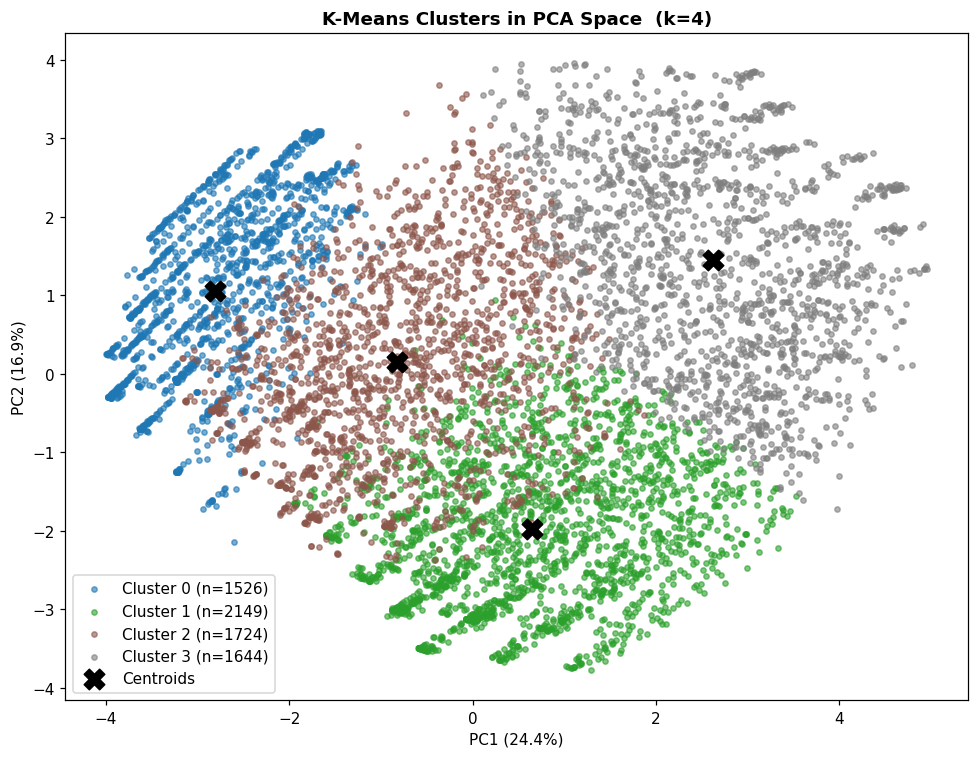

In [ ]:
# PCA 2D visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
cmap = cm.tab10
for c in range(K_FINAL):
    mask = cluster_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               label=f'Cluster {c} (n={mask.sum()})',
               color=cmap(c / K_FINAL), s=12, alpha=0.6)

# Mark centroids
centroids_2d = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=180, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'K-Means Clusters in PCA Space  (k={K_FINAL})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7 — Churn Distribution per Cluster

Now we overlay the churn label to identify which clusters are high-risk.

In [ ]:
# Churn rate per cluster
churn_stats = df_clustered.groupby('cluster')['churn'].agg(
    total='count',
    churned='sum'
)
churn_stats['churn_rate'] = churn_stats['churned'] / churn_stats['total']
churn_stats['not_churned'] = churn_stats['total'] - churn_stats['churned']
overall_rate = churn_label.mean()

print(f'Overall churn rate: {overall_rate:.1%}')
print()
print(churn_stats.round(3).to_string())

Overall churn rate: 26.5%

         total  churned  churn_rate  not_churned
cluster                                         
0         1526      113       0.074         1413
1         2149     1160       0.540          989
2         1724      430       0.249         1294
3         1644      166       0.101         1478


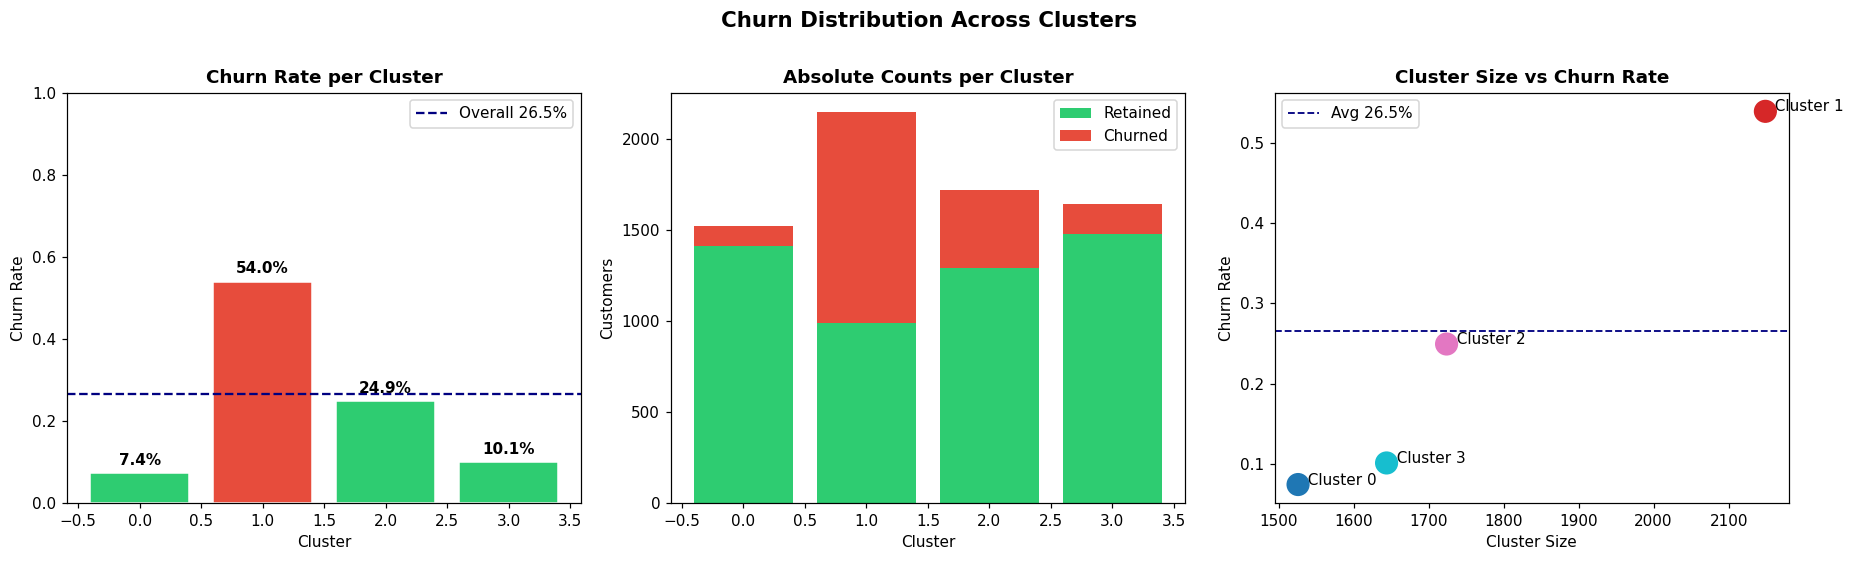

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Plot 1: churn rate per cluster ---
colors = ['#e74c3c' if r > overall_rate else '#2ecc71'
          for r in churn_stats['churn_rate']]
axes[0].bar(churn_stats.index, churn_stats['churn_rate'], color=colors, edgecolor='white')
axes[0].axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall {overall_rate:.1%}')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Churn Rate')
axes[0].set_title('Churn Rate per Cluster', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend()
for i, v in enumerate(churn_stats['churn_rate']):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# --- Plot 2: stacked bar (churned vs retained) ---
axes[1].bar(churn_stats.index, churn_stats['not_churned'], label='Retained', color='#2ecc71')
axes[1].bar(churn_stats.index, churn_stats['churned'],
            bottom=churn_stats['not_churned'], label='Churned', color='#e74c3c')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Customers')
axes[1].set_title('Absolute Counts per Cluster', fontweight='bold')
axes[1].legend()

# --- Plot 3: scatter — cluster size vs churn rate ---
axes[2].scatter(churn_stats['total'], churn_stats['churn_rate'],
                s=200, c=range(K_FINAL), cmap='tab10', zorder=5)
for i, row in churn_stats.iterrows():
    axes[2].annotate(f'  Cluster {i}', (row['total'], row['churn_rate']), fontsize=10)
axes[2].axhline(overall_rate, color='navy', linestyle='--', linewidth=1.2,
                label=f'Avg {overall_rate:.1%}')
axes[2].set_xlabel('Cluster Size'); axes[2].set_ylabel('Churn Rate')
axes[2].set_title('Cluster Size vs Churn Rate', fontweight='bold')
axes[2].legend()

plt.suptitle('Churn Distribution Across Clusters', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

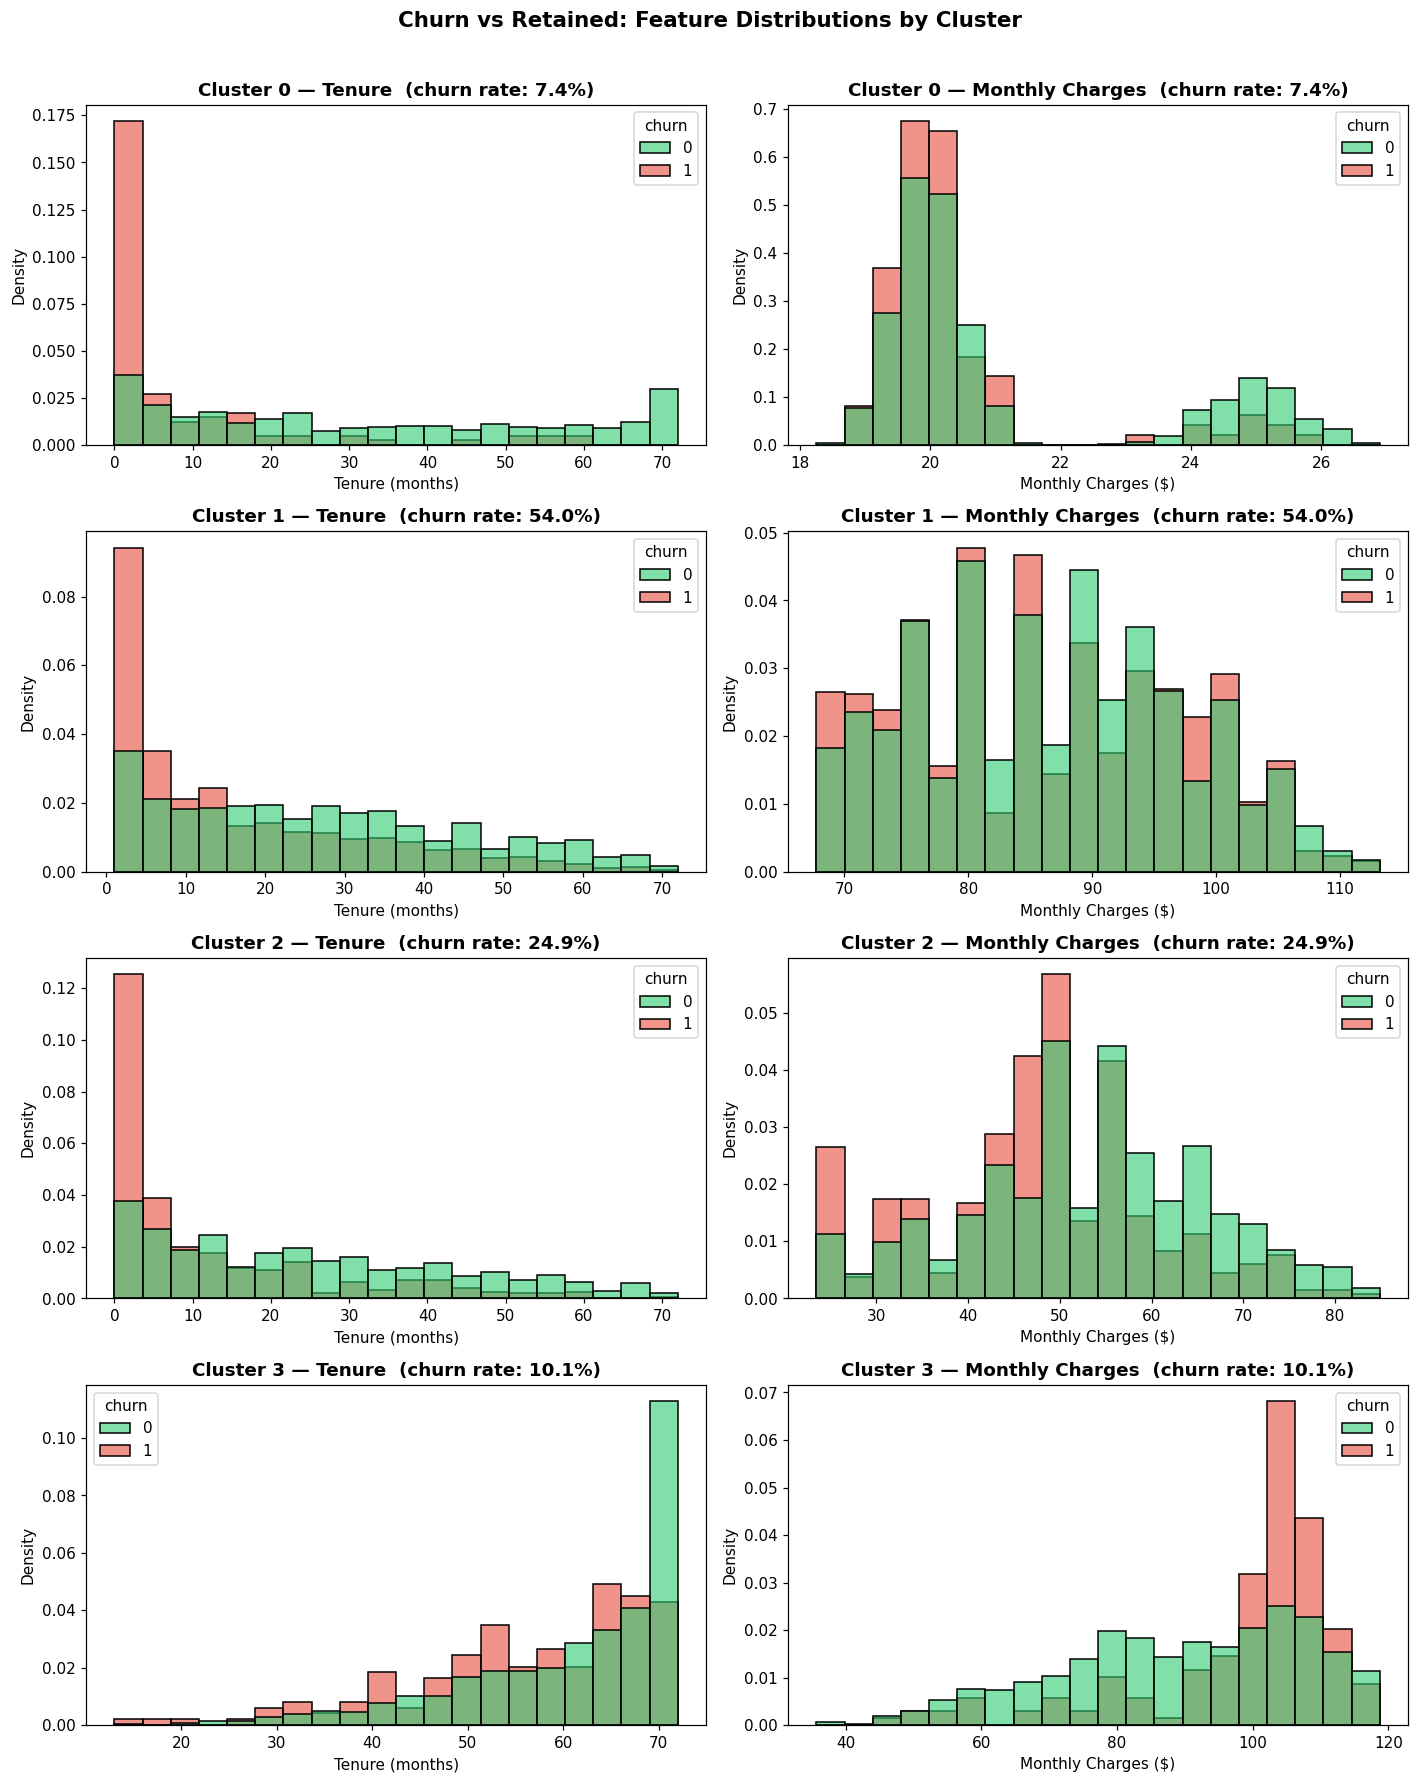

In [ ]:
# Per-cluster churn distribution as KDE / histogram on key features
fig, axes = plt.subplots(K_FINAL, 2, figsize=(13, 4 * K_FINAL))

for c in range(K_FINAL):
    mask = df_clustered['cluster'] == c
    c_data = df_clustered[mask]
    churn_rate_c = c_data['churn'].mean()

    # Tenure distribution
    sns.histplot(data=c_data, x='tenure_raw', hue='churn',
                 bins=20, stat='density', common_norm=False,
                 palette={0: '#2ecc71', 1: '#e74c3c'},
                 alpha=0.6, ax=axes[c, 0])
    axes[c, 0].set_title(f'Cluster {c} — Tenure  (churn rate: {churn_rate_c:.1%})', fontweight='bold')
    axes[c, 0].set_xlabel('Tenure (months)')

    # Monthly charges distribution
    sns.histplot(data=c_data, x='MonthlyCharges_raw', hue='churn',
                 bins=20, stat='density', common_norm=False,
                 palette={0: '#2ecc71', 1: '#e74c3c'},
                 alpha=0.6, ax=axes[c, 1])
    axes[c, 1].set_title(f'Cluster {c} — Monthly Charges  (churn rate: {churn_rate_c:.1%})', fontweight='bold')
    axes[c, 1].set_xlabel('Monthly Charges ($)')

plt.suptitle('Churn vs Retained: Feature Distributions by Cluster',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### ✏️ Question 7.1 — Identifying Churn Clusters

1. Which cluster(s) have a churn rate **significantly above** the overall average? What makes them different (look at the feature profile heatmap from Section 6)?
2. Which cluster(s) are "safe" — low churn rate? What features characterize these customers?
3. Could a cluster be **large and high-churn** at the same time? Why would this cluster be the most urgent business priority even if another cluster has a slightly higher churn rate?

**Your answer:**

1. Cluster 1 has a churn rate significantly above the overall average (54% vs 26.5%). It is characterized by short tenure, high monthly charges, mostly month-to-month contracts, and high paperless billing usage. These customers appear less committed and are therefore more likely to churn.
2. Clusters 0 and 3 are the safest clusters, with churn rates of 7.4% and 10.1%, respectively. Cluster 0 contains low-charge customers with basic service usage, while Cluster 3 contains long-term customers with high engagement, long contracts, and multiple subscribed services.
3. Yes. A cluster can be both large and high-churn. Cluster 1 is the largest cluster (2,149 customers) and also has the highest churn rate (54%). This makes it the most urgent business priority because improving retention in this segment would save the largest number of customers and have the greatest business impact.

---
## 8 — Cluster Naming & Business Recommendations

In [ ]:
# Summary table — all key stats in one place
summary = profiles.copy()
summary['Cluster Size']   = churn_stats['total'].values
summary['Churn Rate']     = churn_stats['churn_rate'].values
summary['Churned (n)']    = churn_stats['churned'].values
summary['Risk Level']     = summary['Churn Rate'].apply(
    lambda r: '🔴 HIGH' if r > overall_rate * 1.3 else ('🟡 MEDIUM' if r > overall_rate * 0.8 else '🟢 LOW')
)

print('=== Full Cluster Summary ===')
summary[['Cluster Size', 'Churn Rate', 'Churned (n)', 'Risk Level',
         'Tenure (months)', 'Monthly Charges ($)', 'Contract (0=Mo, 2=2yr)']].to_string()

=== Full Cluster Summary ===


'         Cluster Size  Churn Rate  Churned (n) Risk Level  Tenure (months)  Monthly Charges ($)  Contract (0=Mo, 2=2yr)\ncluster                                                                                                                \n0                1526    0.074050          113      🟢 LOW            30.55                21.08                    1.07\n1                2149    0.539786         1160     🔴 HIGH            20.82                86.46                    0.08\n2                1724    0.249420          430   🟡 MEDIUM            21.32                51.76                    0.36\n3                1644    0.100973          166      🟢 LOW            60.76                90.59                    1.48'

In [ ]:
display(summary[['Cluster Size', 'Churn Rate', 'Churned (n)', 'Risk Level',
         'Tenure (months)', 'Monthly Charges ($)', 'Contract (0=Mo, 2=2yr)']])

,Cluster Size,Churn Rate,Churned (n),Risk Level,Tenure (months),Monthly Charges ($),"Contract (0=Mo, 2=2yr)"
cluster,,,,,,,
0,1526,0.074050,113,🟢 LOW,30.55,21.08,1.07
1,2149,0.539786,1160,🔴 HIGH,20.82,86.46,0.08
2,1724,0.249420,430,🟡 MEDIUM,21.32,51.76,0.36
3,1644,0.100973,166,🟢 LOW,60.76,90.59,1.48


### ✏️ Question 8.1 — Business Recommendations

For each cluster you identified as high-risk, fill in the table below. Then answer the open questions.

| Cluster | Archetype name | Key features | Recommended action |
|---------|---------------|-------------|--------------------|
| ? | e.g. "Month-to-Month Explorers" | Short tenure, no security add-ons | Offer 3-month loyalty discount + free security trial |
| 1 | High-Risk Month-to-Month Customers|Short tenure, high monthly charges, month-to-month contracts, churn rate 54% | Offer retention discounts, loyalty rewards, and incentives to switch to long-term contracts |

---

**Open questions:**

**Q1 — Prioritization**: If you can only contact 500 customers this week, which cluster do you target first and why? Factor in both the churn rate and the cluster size.

**Q2 — Feature importance**: The model doesn't tell us *why* customers churn — only who they are similar to. What additional data (not in this dataset) would help you understand the root cause of churn in the highest-risk cluster?

**Q3 — Model refresh**: Customer behavior changes over time. How often should this clustering model be retrained? What signal would tell you the current model is stale?

**Q4 — Limitations of K-Means**: K-Means assumes spherical clusters of equal size. Looking at your PCA scatter plot, do the actual clusters look spherical? What alternative algorithm might work better here?

**Q5 — Ethics**: Using behavioral clustering to flag "churn-likely" customers for intervention — is there any risk of unfair treatment? Which customer groups might be inadvertently disadvantaged?

**Your answers:**

**Q1:** If I could only contact 500 customers this week, I would target Cluster 1 first because it has both the highest churn rate (54%) and the largest number of customers (2,149). Retaining customers in this cluster would have the greatest business impact.

**Q2:** Additional data that would help explain churn includes customer satisfaction scores, support ticket history, complaint records, network quality metrics, competitor offers, and customer interaction history. These variables could reveal the root causes behind customer departures.

**Q3:** The clustering model should be retrained every 3–6 months or whenever customer behavior changes significantly. A signal that the model has become stale would be a noticeable shift in churn rates, cluster sizes, or customer feature distributions.

**Q4:** No. The PCA plot shows that the clusters are not perfectly spherical and there is some overlap between groups. An alternative algorithm such as DBSCAN or Hierarchical Clustering may capture more complex cluster shapes and relationships.

**Q5:** Yes. There is a risk of unfair treatment if customers are classified only based on behavioral patterns. Certain groups, such as senior citizens or low-income customers, could be unintentionally disadvantaged if they are systematically targeted differently based on cluster membership. Ethical monitoring and fairness checks should therefore be included in the process.

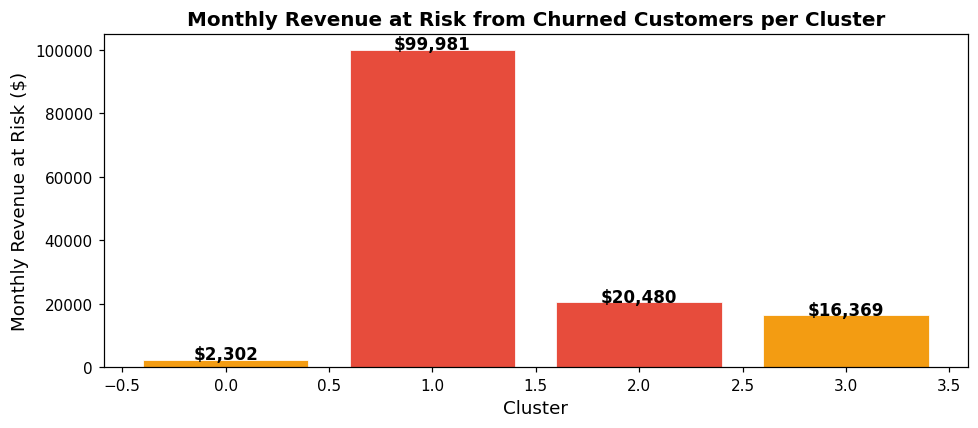

Total monthly revenue at risk: $139,131


In [ ]:
# Final summary chart — expected revenue at risk per cluster
df_clustered['MonthlyCharges_raw'] = df['MonthlyCharges'].values

revenue_risk = df_clustered[df_clustered['churn'] == 1].groupby('cluster')['MonthlyCharges_raw'].sum()
revenue_risk = revenue_risk.rename('Monthly Revenue at Risk ($)')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if c in revenue_risk.nlargest(2).index else '#f39c12'
          for c in revenue_risk.index]
bars = ax.bar(revenue_risk.index, revenue_risk.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Monthly Revenue at Risk ($)', fontsize=12)
ax.set_title('Monthly Revenue at Risk from Churned Customers per Cluster',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, revenue_risk.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 200,
            f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Total monthly revenue at risk: ${revenue_risk.sum():,.0f}')

---
## Summary Checklist

Before submitting, verify:

- [ ] All cells run top to bottom without errors
- [ ] Question 5.1 answered (elbow method interpretation)
- [ ] Question 7.1 answered (identifying churn clusters)
- [ ] Question 8.1 answered — archetype table filled in + all 5 open questions
- [ ] You chose and justified a specific value of K
- [ ] Revenue-at-risk chart is visible

---
*Dataset: IBM Telco Customer Churn — available via GitHub/IBM Developer*